# <span style="color:rgb(213,80,0)">ECM fitting from time dependent measurements</span>

We use the class FittigTime to fit the parameters of a Thevenin model to given time dependent data. The data consists of current and voltage measurement as function of time. Here, we generate synthetically this data using a P2D model

## Setup current input

In [1]:
clear jsonstruct_control
jsonstruct_control.controlPolicy = "timeControl";


vals = [    0     2.5;
          799   2.5;
          800   -1.5;
         1599   -1.5;
         1600    0;
         2799    0;
         2800    3.5;
         4000   3.5];


clear jsonstruct;
jsonstruct.argumentList = {"time"};
jsonstruct.functionFormat = "tabulated";
jsonstruct.dataX = vals(:, 1);
jsonstruct.dataY = vals(:, 2);


jsonstruct_control.value = jsonstruct;


clear jsonstruct;
jsonstruct.argumentList = {"time"};
jsonstruct.functionFormat = "constant";
jsonstruct.value = 1;


jsonstruct_control.type = jsonstruct;


jsonstruct_material = parseBattmoJson(fullfile('ParameterData','ParameterSets','Chen2020','chen2020_lithium_ion_battery.json'));
jsonstruct_geometry = parseBattmoJson(fullfile('Examples', 'JsonDataFiles', 'geometryChen.json'));
jsonstruct = mergeStructs({jsonstruct_material, jsonstruct_geometry});


jsonstruct.Control = jsonstruct_control;
jsonstruct.TimeStepping = struct('totalTime', vals(end, 1), ...
                                 "numberOfTimeSteps", 200);


output = runBattery(jsonstruct);


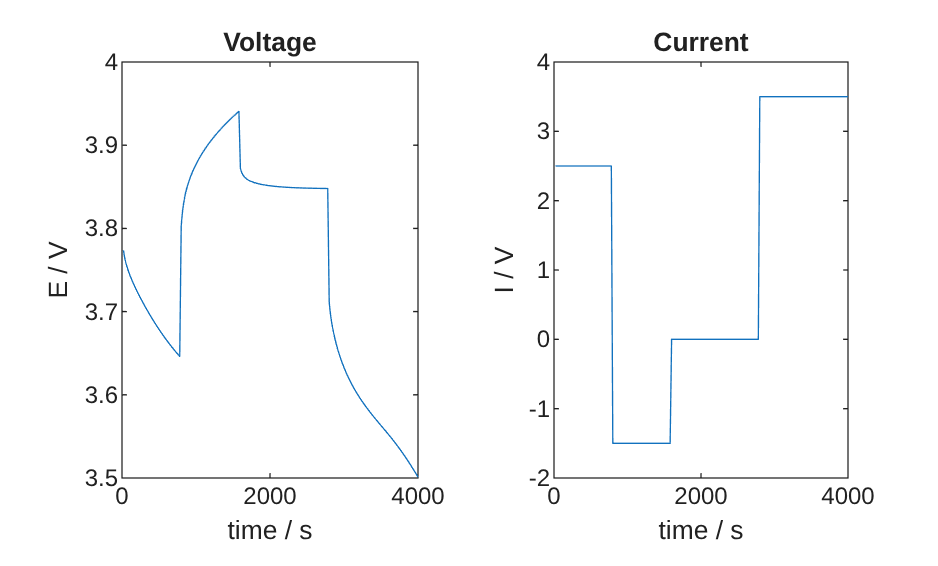

In [2]:


figure
tiledlayout(1, 2);


nexttile
plot(output.time, output.E)
title('Voltage')
xlabel('time / s')
ylabel('E / V');


nexttile
plot(output.time, output.I)
title('Current')
xlabel('time / s')
ylabel('I / V');

It:  0 | val: 5.444e-02 | ls-its: NaN | pgrad: 3.441e+01
It:  1 | val: 4.409e-02 | ls-its:   2 | pgrad: 3.438e+01
It:  2 | val: 4.321e-02 | ls-its:   3 | pgrad: 5.316e-01
It:  3 | val: 4.077e-02 | ls-its:   2 | pgrad: 5.164e-01
It:  4 | val: 4.000e-02 | ls-its:   1 | pgrad: 1.743e+00
It:  5 | val: 3.725e-02 | ls-its:   3 | pgrad: 2.211e+00
It:  6 | val: 2.946e-02 | ls-its:   1 | pgrad: 4.489e+00
It:  7 | val: 2.899e-02 | ls-its:   3 | pgrad: 4.345e+00
It:  8 | val: 2.711e-02 | ls-its:   3 | pgrad: 3.006e+00
It:  9 | val: 2.473e-02 | ls-its:   2 | pgrad: 3.970e+00
It: 10 | val: 2.401e-02 | ls-its:   1 | pgrad: 8.537e+00
It: 11 | val: 2.395e-02 | ls-its:   3 | pgrad: 2.452e+00
It: 12 | val: 2.378e-02 | ls-its:   1 | pgrad: 2.715e+00
It: 13 | val: 2.377e-02 | ls-its:   1 | pgrad: 1.080e+00
It: 14 | val: 2.377e-02 | ls-its:   1 | pgrad: 1.762e-01
It: 15 | val: 2.377e-02 | ls-its:   1 | pgrad: 4.753e-02
It: 16 | val: 2.377e-02 | ls-its:   1 | pgrad: 8.855e-02
It: 17 | val: 2.377e-02 | ls-it


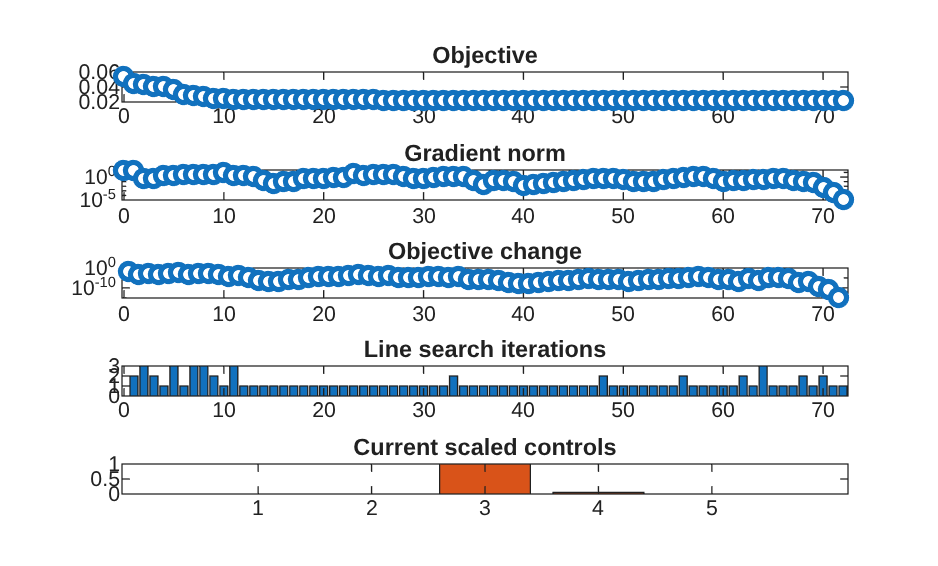

In [3]:
params0 = [5e-2; 1e-1; 6e5; 3e-3; 1e5];


clear inputs
inputs.jsonstruct = jsonstruct;
inputs.output     = output;


clear options
options.useP2Dmodel = true;
options.useSimulationOutput = true;
options.scaleFactor = 1e2;
ftime = FittingTime(params0, inputs, options);


[~, ~, best_params, fitting_error] = ftime.optimizationBFGS();

In [4]:


p = best_params;


## Printing results


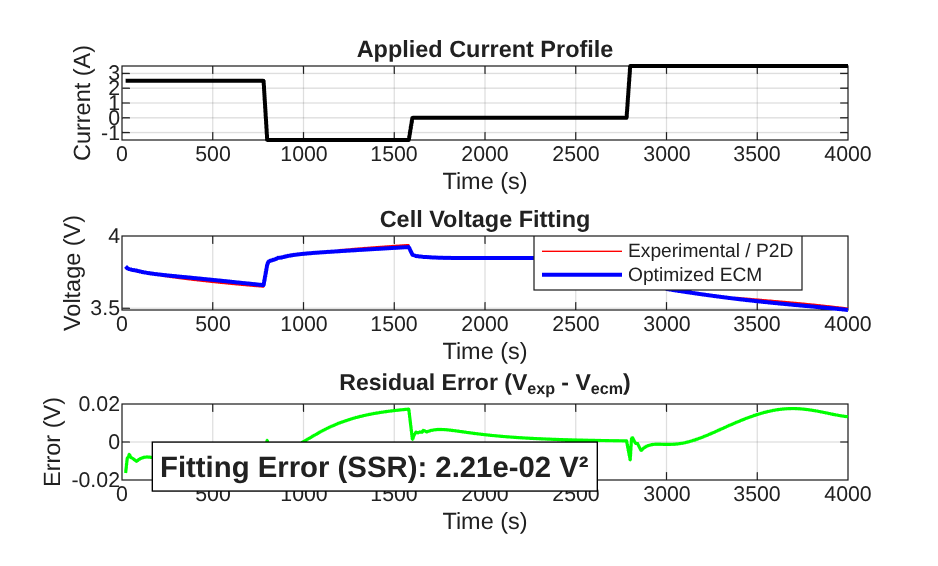

In [5]:
ftime.plotresults_thevenin(best_params, fitting_error);

In [6]:
ftime.printResults(best_params, fitting_error);

         FITTING RESULTS (TIME DOMAIN)     
Total Error (SSR) : 2.2117e-02 V²
R0 : 3.6032e-02 Ohms
R1 : 1.0000e-03 Ohms
C1 : 6.0000e+07 Farads
R2 : 1.5640e-02 Ohms
C2 : 4.6831e+03 Farads